# Quickstart Example: Expanded

Consider solving the simple problem: 

$ \text{min}$ $ x + y_1^2 + y_2^2$

&nbsp; $\text{s.t.} $ $x + y_1 \geq 10$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$x + y_2 \geq 57$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$ 0 \leq x \leq 100$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$x \in \mathbb{R}^1$, $y_1 \in \mathbb{R}^1$, $y_2 \in \mathbb{R}^1$

## Ground-Truth Solution

This is a simple model, for which we can build and solve directly to find the true objective value & variables:

In [6]:
import pyomo.environ as pyo
gurobi = pyo.SolverFactory("gurobi")

full_model = pyo.ConcreteModel()
full_model.x = pyo.Var(domain=pyo.Reals, bounds=(0,100))
full_model.y_1 = pyo.Var(domain=pyo.Reals)
full_model.y_2 = pyo.Var(domain=pyo.Reals)
full_model.obj = pyo.Objective( expr = full_model.x + full_model.y_1**2 + full_model.y_2**2 )
full_model.c1 = pyo.Constraint( expr = full_model.x + full_model.y_1 >= 10 )
full_model.c2 = pyo.Constraint( expr = full_model.x + full_model.y_2 >= 7 ) 

results = gurobi.solve(full_model)
print(f"Full model optimal objective: {pyo.value(full_model.obj)}")
print(f"Full model optimal x: {round(pyo.value(full_model.x),2)}")
print(f"Full model optimal y_1: {round(pyo.value(full_model.y_1),2)}")
print(f"Full model optimal y_2: {round(pyo.value(full_model.y_2),2)}")

Full model optimal objective: 9.750000006234222
Full model optimal x: 9.5
Full model optimal y_1: 0.5
Full model optimal y_2: 0.0


and we can visualize the feasible space, along with the optimal value. Recall, the objective function is nonlinear but the constraint space is fully linear.

In [7]:
from utils import plot_3d
plot_3d(x = pyo.value(full_model.x), 
        y1 = pyo.value(full_model.y_1), 
        y2 = pyo.value(full_model.y_2), 
        opt_obj = pyo.value(full_model.obj))

Solving this directly, we can see where the optimal variable (and associated objective value) falls. 

-------

## Decomposition

This problem has one **complicating variable**, $x$. If we were to *remove* $x$ from the original formulation, 
the resulting formulation is really *two separate* optimization problems combined into one. 

Consider the constraint matrix for this problem:

<p align="center">
  <img src="figures/quickstart-cv.png" width="300">
</p>

If we were to remove $x$, it is trivial to see neither of the two remaining constraints would depend on one another. 
However, removing the complicating variables does not solve the problem we care about. 
Instead, we can utilize this advantageous structure for decomposition within the algorithm for solving the problem.

We can decompose this problem by creating *subproblem-specific copies* of the complicating variable $x$, so that we now have $x_1$ and $x_2$, and then impose a **complicating constraint**. Given the constraint matrix above, it would be transformed as follows:

<p align="center">
  <img src="figures/quickstart-cc.png" width="300">
</p>

Which corresponds to the formulation for subproblem $1$: 

$ \text{min}$ $ \frac{1}{2} x_1 + y_1^2$

&nbsp;$\text{s.t.} $ $x_1 + y_1 \geq 10$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $ 0 \leq x_1 \leq 100$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_1 \in \mathbb{R}^1$, $y_1 \in \mathbb{R}^1$

and subproblem $2$:

$ \text{min}$ $ \frac{1}{2} x_2 + y_2^2$

&nbsp;$\text{s.t.} $ $x_2 + y_2 \geq 7$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $ 0 \leq x_2 \leq 100$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_2 \in \mathbb{R}^1$, $y_2 \in \mathbb{R}^1$

If we were to impose a single complicating constraint that forces $x_1 = x_2$, then we recover the original formulation.
Note: if the complicating constraint (at the bottom) was removed, we would most likely result in a solution where $x_1 \neq x_2$- which does not solve the problem we care about. We will, instead, drop the complicating constraint when forming the lower bound. 



We can visualize what the relaxation will look like by painting the feasible regions for both of the subproblems. This is essentially a projection onto the variable space of the subproblem - specific variables. 

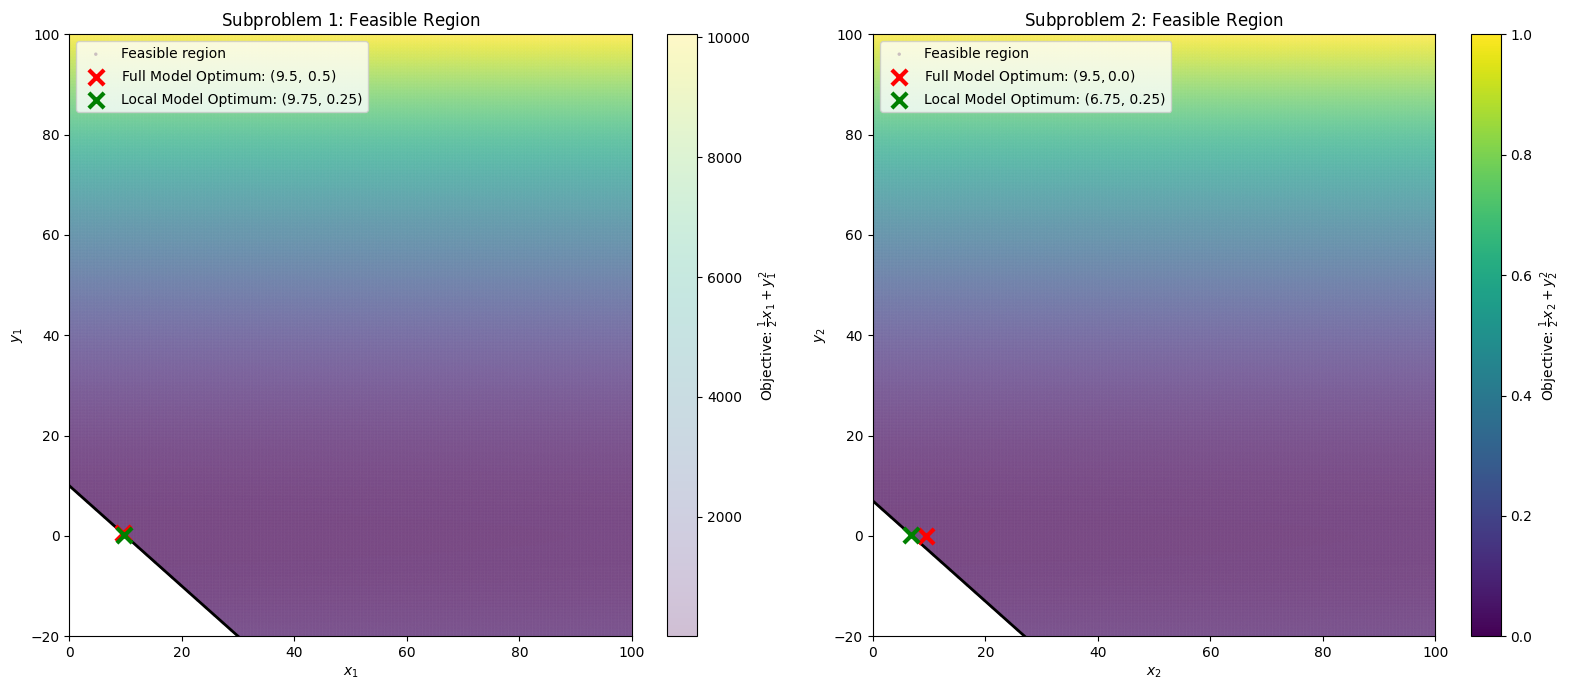

In [8]:
from utils import plot_feasible_regions
plot_feasible_regions()

The lower bound will perform the following:

<p align="center">
  <img src="figures/quickstart-lb.png" width="300">
</p>

We will solve subproblem $1$ and then subproblem $2$, where the bounds on the complicating variable copies $x_1$ and $x_2$ are both the same; in this case, $x^{\text{LB}}=0$ and $x^{\text{LB}}=100$. We will branch on this continuous domain, refining it as we search along the tree. In the limit, the range of between $x^{\text{LB}}$ and $x^{\text{LB}}$ will grow infinitesimally small, essentially converging to a point where  $x^{\text{LB}} \approx x^{\text{LB}}$- which would result in a lower bound that *is* solving the problem we care about! However, we hope to prune subdomains (via bound/infeasibility) before we have to get to pure enumeration.

This is exactly what `SNoGloDe` does at its core. 

In [9]:
import snoglode as sno

def subproblem_creator(name):
    m = pyo.ConcreteModel()
    m.x = pyo.Var(domain=pyo.Reals,
                  bounds = (0, 100))
    if name == "1":
        m.y_1 = pyo.Var(domain=pyo.Reals)
        m.obj = pyo.Objective( expr = (1/2)*m.x + m.y_1**2 )
        m.c = pyo.Constraint( expr = m.x + m.y_1 >= 10 )
    if name == "2":
        m.y_2 = pyo.Var(domain=pyo.Reals)
        m.obj = pyo.Objective( expr = (1/2)*m.x + m.y_2**2 )
        m.c = pyo.Constraint( expr = m.x + m.y_2 >= 57 )
    return m, {"x": m.x}, 1

subproblem_names = ["1", "2"]
params = sno.SolverParameters(subproblem_names = subproblem_names,
                              subproblem_creator = subproblem_creator,
                              lb_solver = gurobi,
                              cg_solver = gurobi,
                              ub_solver = gurobi)

solver = sno.Solver(params)
solver.solve(max_iter=100, rel_tolerance=1e-4, collect_plot_info=True)
print(f"The best primal/feasible solution has a value of: {solver.tree.metrics.ub}")
print(f"The best lower bound solution has a value of: {solver.tree.metrics.lb}")
print(f"Decomposition optimal x: {round(pyo.value(solver.subproblems.model["1"].x),2)}")
print(f"Decomposition optimal y_1: {round(pyo.value(solver.subproblems.model["1"].y_1),2)}")
print(f"Decomposition optimal y_2: {round(pyo.value(solver.subproblems.model["2"].y_2),2)}")

        Time (s)  Nodes Explored       Pruned by                              LB              UB        Rel. Gap        Abs. Gap         # Nodes
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           0.012               1                           * L U          33.375           56.75        41.1894%          23.375               2
           0.017               2           Bound                          33.375           56.75        41.1894%          23.375               1
           0.025               3                           * L           53.4375           56.75          5.837%          3.3125               2
           0.035               4                           * L           53.4375           56.75          5.837%          3.3125               3
           0.046               5                           * L           53.4375           56.75       

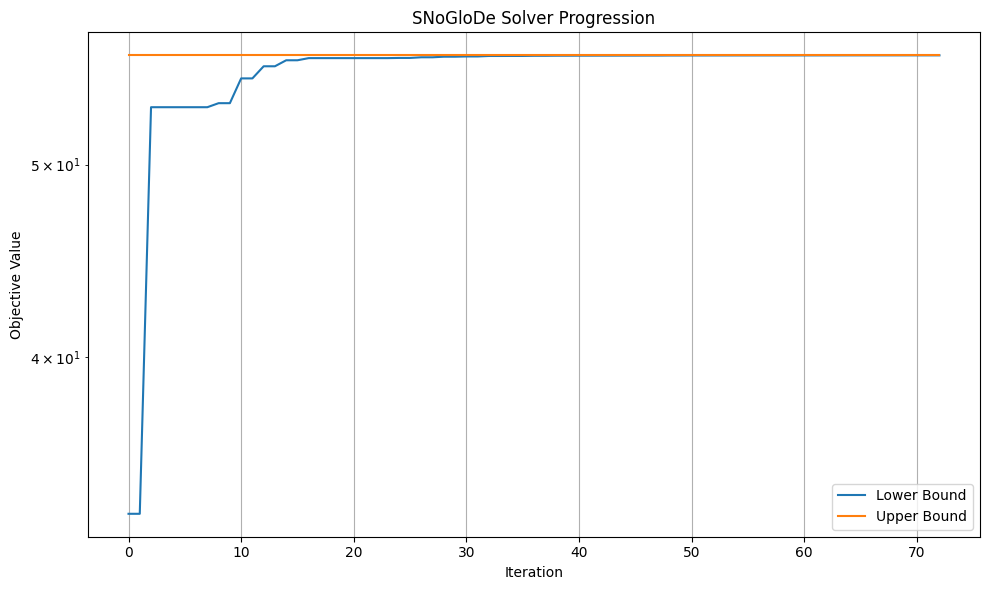

In [10]:
from utils import plot_results
plot_results(solver)